In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest, chi2 # feature selection
from sklearn.tree import DecisionTreeClassifier,plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import seaborn as sns
import matplotlib.pyplot as plt
import warnings
import pickle
warnings.filterwarnings("ignore")

training_times = {}

## ***Read the dataset with pandas***


In [2]:
df = pd.read_csv('StealthPhisher.csv')
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

df.head()


Shape: (336749, 65)

Columns:
['URL', 'LengthOfURL', 'Domain', 'URLComplexity', 'CharacterComplexity', 'DomainLengthOfURL', 'IsDomainIP', 'TLD', 'TLDLength', 'LetterCntInURL', 'URLLetterRatio', 'DigitCntInURL', 'URLDigitRatio', 'EqualCharCntInURL', 'QuesMarkCntInURL', 'AmpCharCntInURL', 'OtherSpclCharCntInURL', 'URLOtherSpclCharRatio', 'NumberOfHashtags', 'NumberOfSubdomains', 'HavingPath', 'PathLength', 'HavingQuery', 'HavingFragment', 'HavingAnchor', 'HasSSL', 'IsUnreachable', 'LineOfCode', 'LongestLineLength', 'HasTitle', 'HasFavicon', 'HasRobotsBlocked', 'IsResponsive', 'IsURLRedirects', 'IsSelfRedirects', 'HasDescription', 'HasPopup', 'HasIFrame', 'IsFormSubmitExternal', 'HasSocialMediaPage', 'HasSubmitButton', 'HasHiddenFields', 'HasPasswordFields', 'HasBankingKey', 'HasPaymentKey', 'HasCryptoKey', 'HasCopyrightInfoKey ', 'CntImages', 'CntFilesCSS', 'CntFilesJS', 'CntSelfHRef', 'CntEmptyRef', 'CntExternalRef', 'CntPopup', 'CntIFrame', 'UniqueFeatureCnt', 'WAPLegitimate', 'WAPPhis

,URL,LengthOfURL,Domain,URLComplexity,CharacterComplexity,DomainLengthOfURL,IsDomainIP,TLD,TLDLength,LetterCntInURL,...,UniqueFeatureCnt,WAPLegitimate,WAPPhishing,ShannonEntropy,FractalDimension,KolmogorovComplexity,HexPatternCnt,Base64PatternCnt,LikelinessIndex,Label
0,https://bafkreibre4pwizu3d73y7at37ewy6nhklfhb4...,84,bafkreibre4pwizu3d73y7at37ewy6nhklfhb4mb75tp25...,14.000,0.013158,76,0,com,3,55,...,0,0.036909,0.034343,4.739567,1.00,1.000000,1,3,0.263200,Phishing
1,http://101.200.220.118:8090/ledshow2.exe,40,101.200.220.118:8090,12.000,0.030303,20,1,118:8090,8,10,...,0,0.030220,0.031712,3.808271,1.00,1.222222,5,3,0.329167,Phishing
2,https://1llc5nv.duckdns.org/,28,1llc5nv.duckdns.org,9.000,0.050000,19,0,org,3,15,...,0,0.043893,0.038140,4.056021,0.75,1.307692,0,2,0.684211,Phishing
3,http://hrga.melonwoodhomes.com/,31,hrga.melonwoodhomes.com,9.375,0.041667,23,0,com,3,21,...,0,0.061778,0.046342,3.827833,0.75,1.275862,0,2,0.608696,Phishing
4,https://www.aspb.gob.bo,23,www.aspb.gob.bo,5.875,0.066667,15,0,bo,2,9,...,10,0.073055,0.046233,3.346439,1.00,1.400000,0,2,0.733333,Legitimate


 Basic cleaning

- Strip extra spaces from column names
- Check missing values
- Identify the target column


In [3]:
# Clean column names
df.columns = df.columns.str.strip()

print("Missing values per column:")
print(df.isnull().sum().sort_values(ascending=False).head(15))

target_col = "Label"
print("\nTarget column:", target_col)
print("\nTarget distribution:")
print(df[target_col].value_counts(dropna=False))


Missing values per column:
TLD                    2
URL                    0
LengthOfURL            0
URLComplexity          0
Domain                 0
CharacterComplexity    0
DomainLengthOfURL      0
IsDomainIP             0
TLDLength              0
LetterCntInURL         0
URLLetterRatio         0
DigitCntInURL          0
URLDigitRatio          0
EqualCharCntInURL      0
QuesMarkCntInURL       0
dtype: int64

Target column: Label

Target distribution:
Label
Phishing      175806
Legitimate    160943
Name: count, dtype: int64


## ***Separate features and target***


In [4]:
# Separate features and target
X = df.drop(columns=[target_col]).copy()
y = df[target_col].copy()

# High-cardinality text columns to drop
drop_cols = [col for col in ["URL", "Domain"] if col in X.columns]
X = X.drop(columns=drop_cols)

print("Dropped columns:", drop_cols)
print("Remaining feature shape:", X.shape)


Dropped columns: ['URL', 'Domain']
Remaining feature shape: (336749, 62)


## ***Encode the target label***

`Legitimate` / `Phishing` will be converted to numeric labels.


In [5]:
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print("Classes:", list(label_encoder.classes_))
print("Encoded target sample:", y_encoded[:10])


Classes: ['Legitimate', 'Phishing']
Encoded target sample: [1 1 1 1 0 1 1 0 1 0]


## ***Detect numeric and categorical columns***




In [6]:
categorical_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()
numeric_cols = X.select_dtypes(exclude=["object", "category"]).columns.tolist()

print("Categorical columns:", categorical_cols)
print("\nNumber of numeric columns:", len(numeric_cols))


Categorical columns: ['TLD']

Number of numeric columns: 61


## ***Train/test split***


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)


X_train: (269399, 62)
X_test: (67350, 62)


## ***Preprocessing and feature selection***



In [8]:
k_features = 40

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, categorical_cols)
    ]
)

In [9]:
print("Feature Selection Summary")
print("Features BEFORE selection:", X_train.shape[1])
print("Features AFTER selection:", k_features)

Feature Selection Summary
Features BEFORE selection: 62
Features AFTER selection: 40


## ***Decision Tree pipeline***


In [10]:
dt_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("selector", SelectKBest(score_func=chi2, k=k_features)),
    ("model", DecisionTreeClassifier(
        random_state=42,
        max_depth=10,
        min_samples_split=10,
        min_samples_leaf=5
    ))
])

dt_pipeline.fit(X_train, y_train)
dt_pred = dt_pipeline.predict(X_test)

print("Decision Tree Accuracy:", round(accuracy_score(y_test, dt_pred), 4))
print("\nClassification Report:")
print(classification_report(y_test, dt_pred, target_names=label_encoder.classes_))


Decision Tree Accuracy: 0.9959

Classification Report:
              precision    recall  f1-score   support

  Legitimate       0.99      1.00      1.00     32189
    Phishing       1.00      1.00      1.00     35161

    accuracy                           1.00     67350
   macro avg       1.00      1.00      1.00     67350
weighted avg       1.00      1.00      1.00     67350



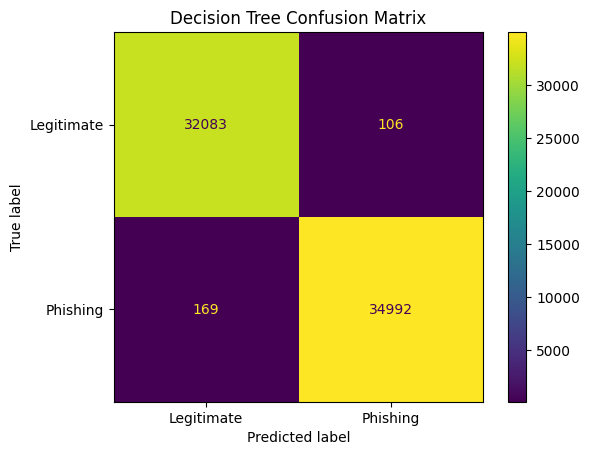

In [11]:
dt_pred = dt_pipeline.predict(X_test)
cm_dt = confusion_matrix(y_test, dt_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_dt, display_labels=label_encoder.classes_)
disp.plot()
plt.title("Decision Tree Confusion Matrix")
plt.show()


In [12]:
dt_model = dt_pipeline.named_steps["model"]

numeric_features = numeric_cols

categorical_features = dt_pipeline.named_steps['preprocessor'].named_transformers_['cat'] \
                        .named_steps['onehot'].get_feature_names_out(categorical_cols)

all_features = np.concatenate([numeric_features, categorical_features])

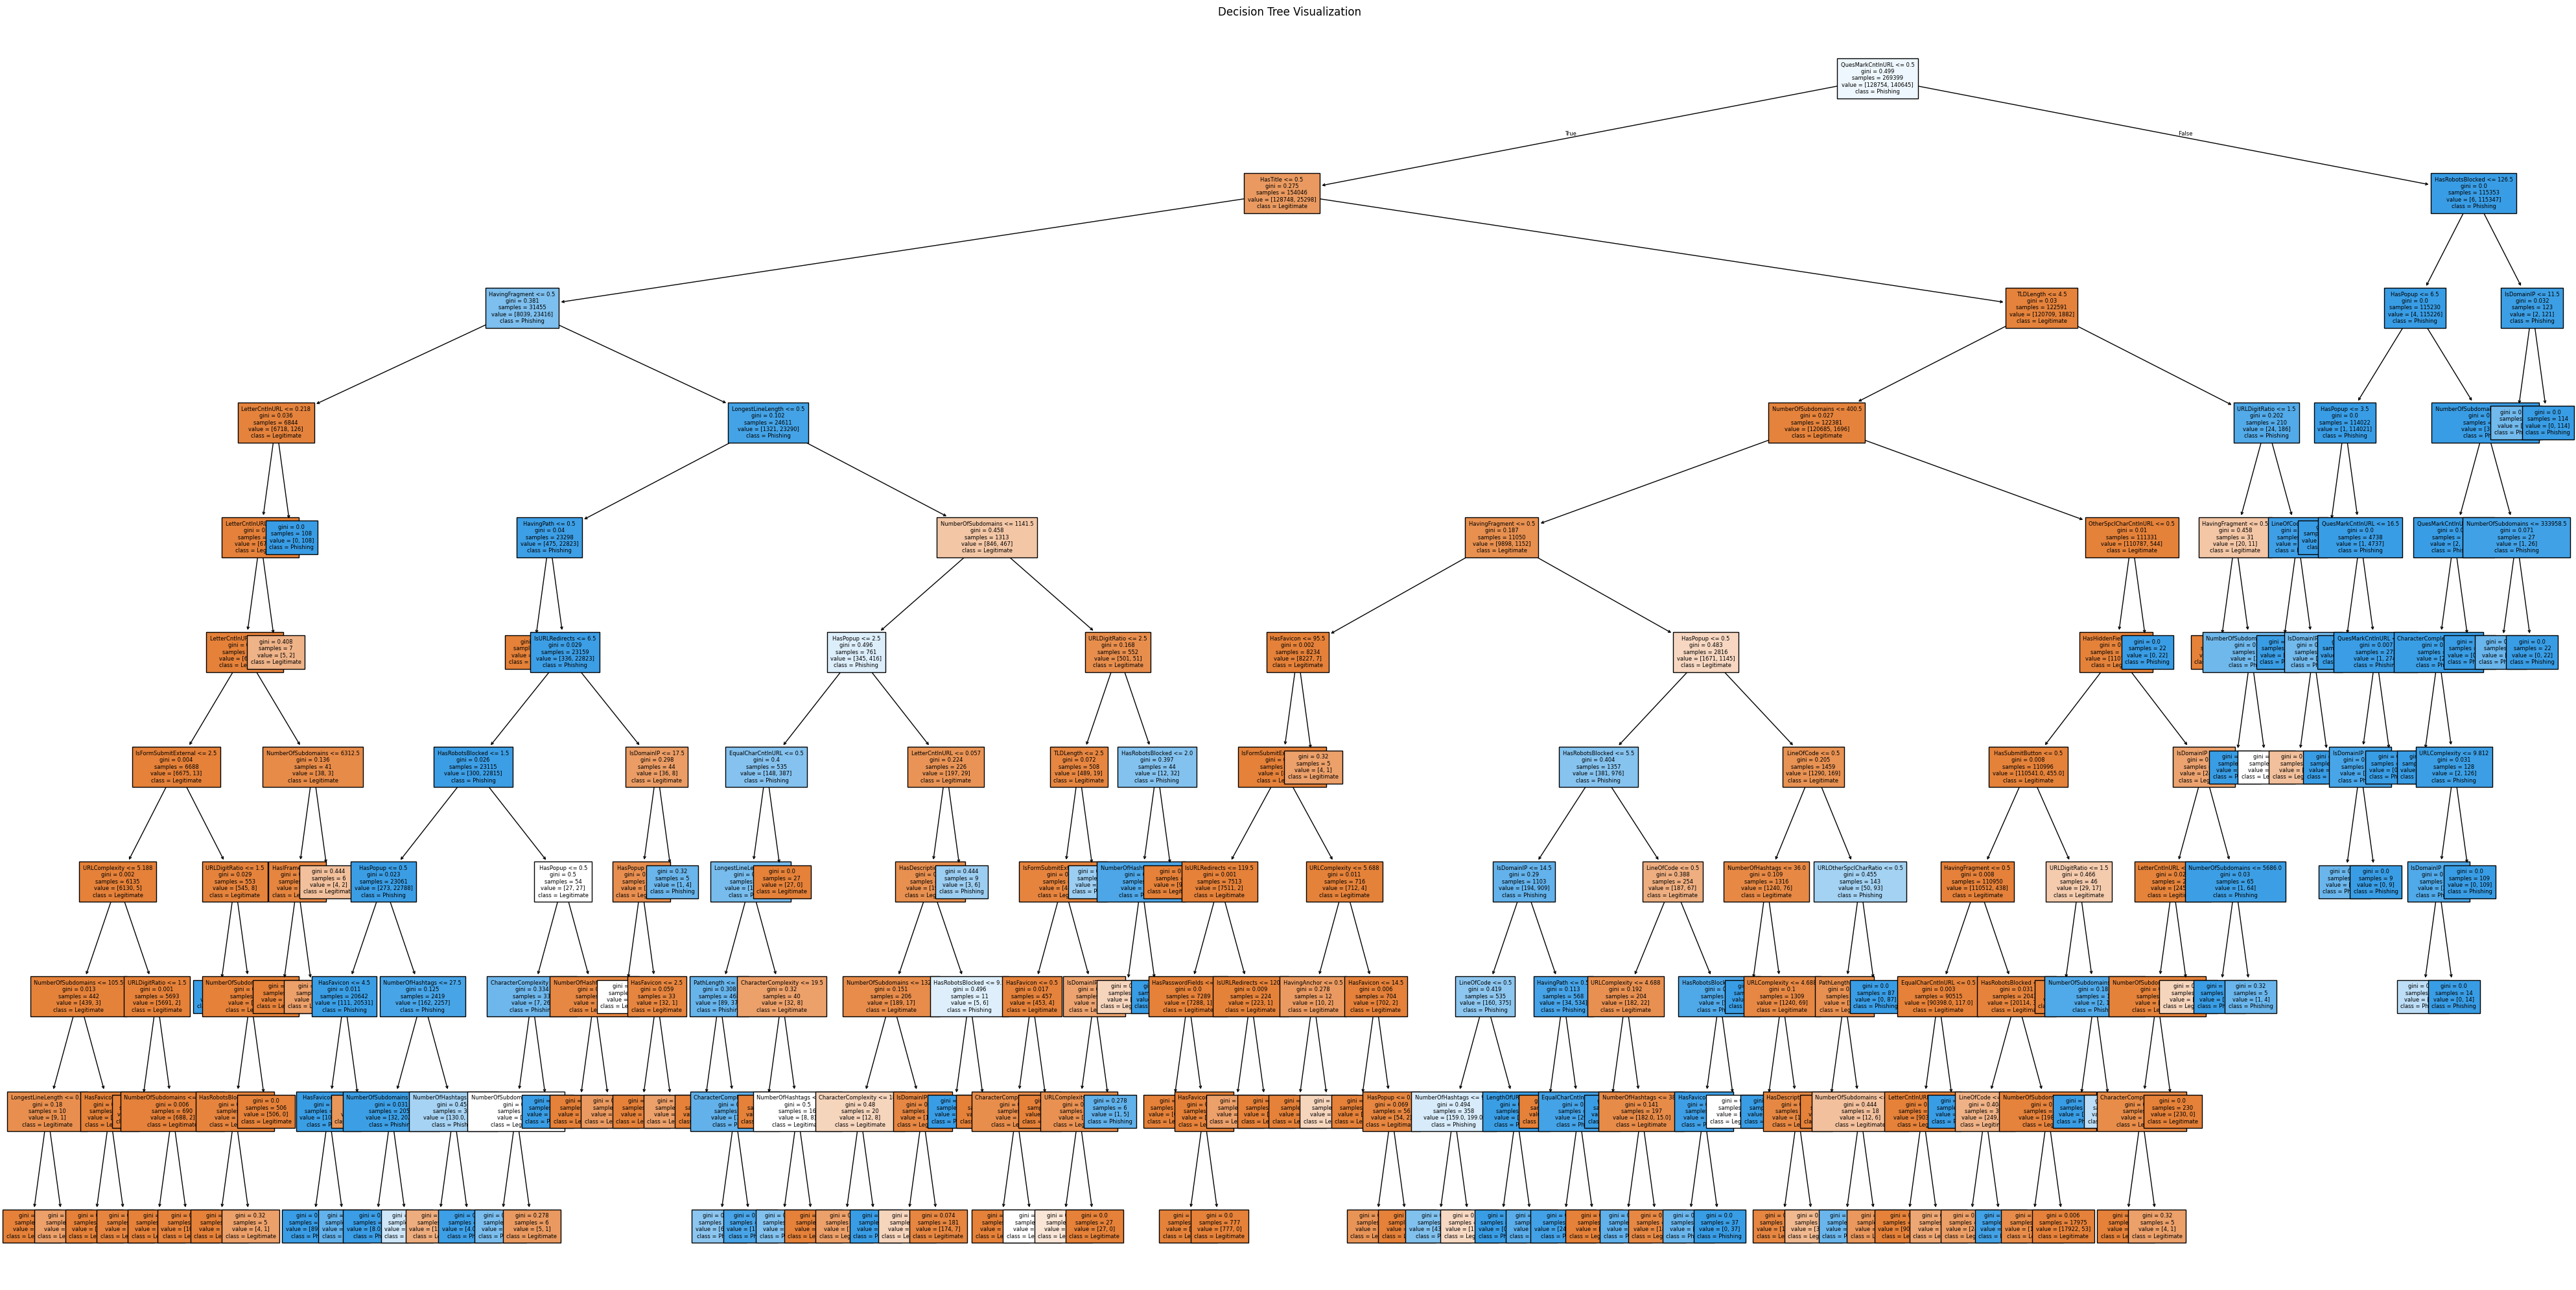

In [13]:
plt.figure(figsize=(40, 20))
plot_tree(
    dt_model,
    feature_names=all_features,
    class_names=label_encoder.classes_,
    filled=True,
    fontsize=6,
)
plt.title("Decision Tree Visualization")
plt.tight_layout()
plt.show()

# **Training Time**

In [14]:
import time

start = time.time()
dt_pipeline.fit(X_train, y_train)
training_times["Decision Tree"] = time.time() - start

dt_pred = dt_pipeline.predict(X_test)

## ***Random Forest***

In [15]:
rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("selector", SelectKBest(score_func=chi2, k=k_features)),
    ("model", RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        max_depth=15,
        min_samples_split=10,
        min_samples_leaf=4,
        n_jobs=-1
    ))
])

rf_pipeline.fit(X_train, y_train)
rf_pred = rf_pipeline.predict(X_test)

print("Random Forest Accuracy:", round(accuracy_score(y_test, rf_pred), 4))
print("\nClassification Report:")
print(classification_report(y_test, rf_pred, target_names=label_encoder.classes_))


Random Forest Accuracy: 0.9969

Classification Report:
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     32189
    Phishing       1.00      1.00      1.00     35161

    accuracy                           1.00     67350
   macro avg       1.00      1.00      1.00     67350
weighted avg       1.00      1.00      1.00     67350



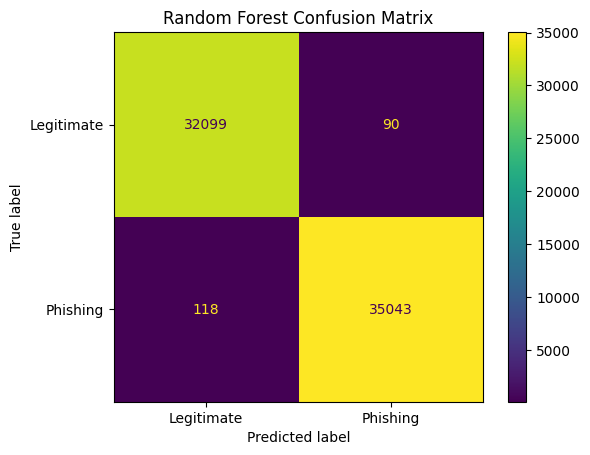

In [16]:
cm_rf = confusion_matrix(y_test, rf_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=label_encoder.classes_)
disp.plot()
plt.title("Random Forest Confusion Matrix")
plt.show()


# **Execution Time**

In [17]:
start = time.time()
rf_pipeline.fit(X_train, y_train)
training_times["Random Forest"] = time.time() - start

rf_pred = rf_pipeline.predict(X_test)

## ***Compare both models***


In [18]:
results = pd.DataFrame({
    "Model": ["Decision Tree", "Random Forest"],
    "Accuracy": [
        accuracy_score(y_test, dt_pred),
        accuracy_score(y_test, rf_pred)
    ]
})

results.sort_values(by="Accuracy", ascending=False)


,Model,Accuracy
1,Random Forest,0.996912
0,Decision Tree,0.995917


## ***View selected features***

In [19]:
# Get encoded feature names from the preprocessor
encoded_feature_names = dt_pipeline.named_steps["preprocessor"].get_feature_names_out()

# Get mask of selected features
selected_mask = dt_pipeline.named_steps["selector"].get_support()
selected_features = np.array(encoded_feature_names)[selected_mask]

print("Number of selected features:", len(selected_features))
print("\nSelected features:")
for f in selected_features:
    print(f)


Number of selected features: 40

Selected features:
num__LengthOfURL
num__URLComplexity
num__DomainLengthOfURL
num__IsDomainIP
num__LetterCntInURL
num__DigitCntInURL
num__URLDigitRatio
num__EqualCharCntInURL
num__QuesMarkCntInURL
num__OtherSpclCharCntInURL
num__HavingPath
num__PathLength
num__HavingQuery
num__HavingFragment
num__HavingAnchor
num__LineOfCode
num__LongestLineLength
num__HasFavicon
num__HasRobotsBlocked
num__IsResponsive
num__IsSelfRedirects
num__HasDescription
num__HasSubmitButton
num__HasPaymentKey
num__HasCopyrightInfoKey
num__CntImages
num__CntFilesCSS
num__CntFilesJS
num__CntSelfHRef
num__CntEmptyRef
num__CntExternalRef
num__CntPopup
num__CntIFrame
num__UniqueFeatureCnt
num__HexPatternCnt
num__Base64PatternCnt
cat__TLD_240
cat__TLD_dev
cat__TLD_io
cat__TLD_org


# ***Logic Regresion***

In [20]:
from sklearn.linear_model import LogisticRegression

lr_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("selector", SelectKBest(score_func=chi2, k=k_features)),
    ("model", LogisticRegression(max_iter=1000, random_state=42))
])

lr_pipeline.fit(X_train, y_train)

lr_pred = lr_pipeline.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, lr_pred))

print("\nClassification Report:")
print(classification_report(y_test, lr_pred))

Logistic Regression Accuracy: 0.9827765404602821

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98     32189
           1       0.98      0.98      0.98     35161

    accuracy                           0.98     67350
   macro avg       0.98      0.98      0.98     67350
weighted avg       0.98      0.98      0.98     67350



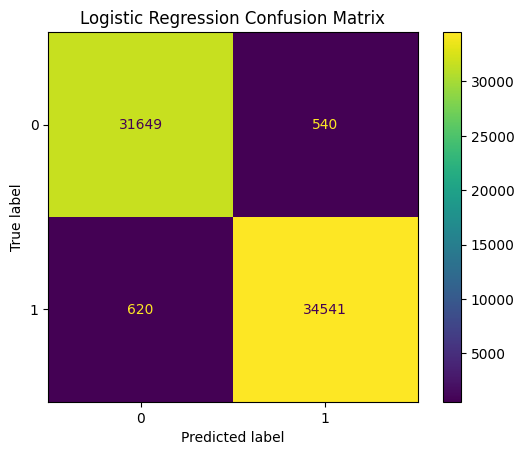

In [21]:
cm = confusion_matrix(y_test, lr_pred)
disp = ConfusionMatrixDisplay(cm)

disp.plot()
plt.title("Logistic Regression Confusion Matrix")
plt.show()

# **Training Time**

In [22]:
start = time.time()
lr_pipeline.fit(X_train, y_train)
training_times["Logistic Regression"] = time.time() - start

lr_pred = lr_pipeline.predict(X_test)

# ***Support Vector Machine***

In [23]:
from sklearn.svm import LinearSVC

In [24]:
svm_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("selector", SelectKBest(score_func=chi2, k=k_features)),
    ("model", LinearSVC(random_state=42, max_iter=5000))
])

svm_pipeline.fit(X_train, y_train)

svm_pred = svm_pipeline.predict(X_test)

print("SVM Accuracy:", accuracy_score(y_test, svm_pred))

print("\nClassification Report:")
print(classification_report(y_test, svm_pred))

SVM Accuracy: 0.9479881217520416

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.91      0.94     32189
           1       0.92      0.98      0.95     35161

    accuracy                           0.95     67350
   macro avg       0.95      0.95      0.95     67350
weighted avg       0.95      0.95      0.95     67350



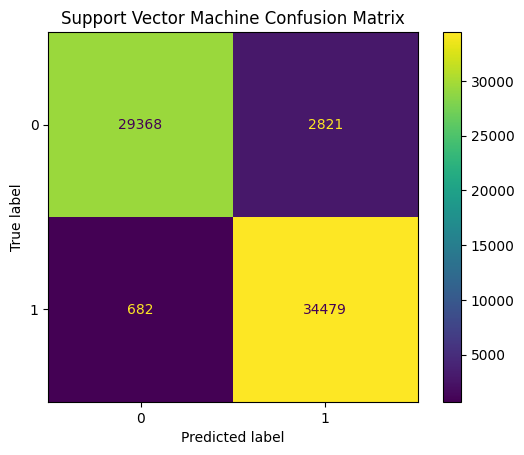

In [25]:
cm = confusion_matrix(y_test, svm_pred)
disp = ConfusionMatrixDisplay(cm)

disp.plot()
plt.title("Support Vector Machine Confusion Matrix")
plt.show()

# **Training Time**

In [26]:
start = time.time()
svm_pipeline.fit(X_train, y_train)
training_times["Support Vector Machine"] = time.time() - start

svm_pred = svm_pipeline.predict(X_test)

# ***Multi-Layer Perception***

In [27]:
from sklearn.neural_network import MLPClassifier

In [28]:
mlp_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("selector", SelectKBest(score_func=chi2, k=k_features)),
    ("model", MLPClassifier(
        hidden_layer_sizes=(100,),
        max_iter=300,
        random_state=42
    ))
])

mlp_pipeline.fit(X_train, y_train)

mlp_pred = mlp_pipeline.predict(X_test)

print("MLP Accuracy:", accuracy_score(y_test, mlp_pred))

print("\nClassification Report:")
print(classification_report(y_test, mlp_pred))

MLP Accuracy: 0.9728730512249443

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.99      0.97     32189
           1       1.00      0.95      0.97     35161

    accuracy                           0.97     67350
   macro avg       0.97      0.97      0.97     67350
weighted avg       0.97      0.97      0.97     67350



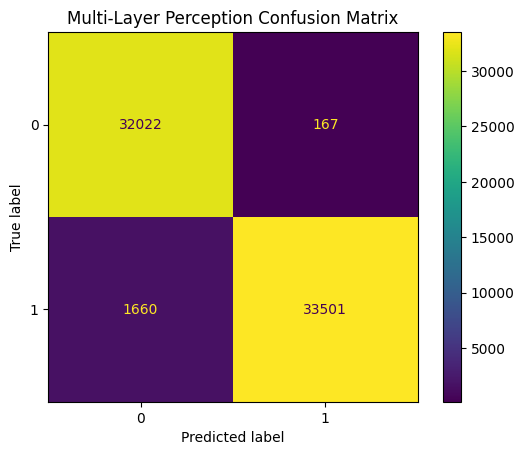

In [29]:
cm = confusion_matrix(y_test, mlp_pred)
disp = ConfusionMatrixDisplay(cm)

disp.plot()
plt.title("Multi-Layer Perception Confusion Matrix")
plt.show()

# **Training Time**

In [30]:
start = time.time()
mlp_pipeline.fit(X_train, y_train)
training_times["Multi-Layer Perception"] = time.time() - start

mlp_pred = mlp_pipeline.predict(X_test)

# ***Long Short-Term Memory***

In [31]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

In [32]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

In [33]:
selector = SelectKBest(score_func=chi2, k=k_features)

X_train_selected = selector.fit_transform(X_train_processed, y_train)
X_test_selected = selector.transform(X_test_processed)

In [34]:
X_train_selected = X_train_selected.toarray()
X_test_selected = X_test_selected.toarray()

In [35]:
X_train_lstm = X_train_selected.reshape((X_train_selected.shape[0], 1, X_train_selected.shape[1]))
X_test_lstm = X_test_selected.reshape((X_test_selected.shape[0], 1, X_test_selected.shape[1]))

In [36]:
model = Sequential([
    LSTM(64, input_shape=(1, X_train_selected.shape[1])),
    Dense(1, activation='sigmoid')
])

In [37]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [38]:
model.fit(
    X_train_lstm,
    y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.1
)

Epoch 1/5
3789/3789 ━━━━━━━━━━━━━━━━━━━━ 17s 4ms/step - accuracy: 0.8908 - loss: 0.2540 - val_accuracy: 0.9170 - val_loss: 0.1870
Epoch 2/5
3789/3789 ━━━━━━━━━━━━━━━━━━━━ 14s 4ms/step - accuracy: 0.9148 - loss: 0.1913 - val_accuracy: 0.9001 - val_loss: 0.1956
Epoch 3/5
3789/3789 ━━━━━━━━━━━━━━━━━━━━ 14s 4ms/step - accuracy: 0.9171 - loss: 0.1826 - val_accuracy: 0.9217 - val_loss: 0.1638
Epoch 4/5
3789/3789 ━━━━━━━━━━━━━━━━━━━━ 14s 4ms/step - accuracy: 0.9136 - loss: 0.1823 - val_accuracy: 0.9375 - val_loss: 0.1420
Epoch 5/5
3789/3789 ━━━━━━━━━━━━━━━━━━━━ 14s 4ms/step - accuracy: 0.9150 - loss: 0.1823 - val_accuracy: 0.9007 - val_loss: 0.2070


In [39]:
lstm_probs = model.predict(X_test_lstm) #make predictions

lstm_pred = (lstm_probs > 0.5).astype(int)
lstm_pred = lstm_pred.flatten()

print("LSTM Accuracy:", accuracy_score(y_test, lstm_pred))

print("\nClassification Report:")
print(classification_report(y_test, lstm_pred))

2105/2105 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step
LSTM Accuracy: 0.9039198218262806

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.99      0.91     32189
           1       0.99      0.82      0.90     35161

    accuracy                           0.90     67350
   macro avg       0.91      0.91      0.90     67350
weighted avg       0.92      0.90      0.90     67350



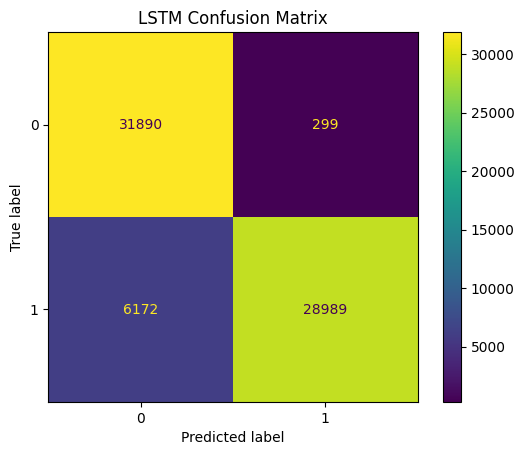

In [40]:
cm = confusion_matrix(y_test, lstm_pred)
disp = ConfusionMatrixDisplay(cm)

disp.plot()
plt.title("LSTM Confusion Matrix")
plt.show()

# **Execution Time**

In [41]:
start = time.time()

model.fit(
    X_train_lstm,
    y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.1
)

training_times["LSTM"] = time.time() - start

Epoch 1/5
3789/3789 ━━━━━━━━━━━━━━━━━━━━ 14s 4ms/step - accuracy: 0.9186 - loss: 0.1734 - val_accuracy: 0.9279 - val_loss: 0.1651
Epoch 2/5
3789/3789 ━━━━━━━━━━━━━━━━━━━━ 14s 4ms/step - accuracy: 0.9185 - loss: 0.1701 - val_accuracy: 0.9330 - val_loss: 0.1599
Epoch 3/5
3789/3789 ━━━━━━━━━━━━━━━━━━━━ 13s 4ms/step - accuracy: 0.9269 - loss: 0.1535 - val_accuracy: 0.8834 - val_loss: 0.1971
Epoch 4/5
3789/3789 ━━━━━━━━━━━━━━━━━━━━ 13s 4ms/step - accuracy: 0.9227 - loss: 0.1621 - val_accuracy: 0.9165 - val_loss: 0.1501
Epoch 5/5
3789/3789 ━━━━━━━━━━━━━━━━━━━━ 14s 4ms/step - accuracy: 0.9261 - loss: 0.1536 - val_accuracy: 0.9232 - val_loss: 0.1627


# ***Comparison of models***

In [42]:
models = {
    "Decision Tree": dt_pred,
    "Random Forest": rf_pred,
    "Logistic Regression": lr_pred,
    "SVM": svm_pred,
    "MLP": mlp_pred,
    "LSTM": lstm_pred
}

results_list = []

for name, pred in models.items():

    report = classification_report(
        y_test,
        pred,
        target_names=label_encoder.classes_,
        output_dict=True
    )

    weighted_metrics = report['weighted avg']

    results_list.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": weighted_metrics['precision'],
        "Recall": weighted_metrics['recall'],
        "F1 Score": weighted_metrics['f1-score'],
        "Training Time (s)": round(training_times.get(name, 0), 2)
    })

results_df = pd.DataFrame(results_list)

results_df = results_df.sort_values(by="F1 Score", ascending=False)

results_df = results_df.round(4)

results_df

,Model,Accuracy,Precision,Recall,F1 Score,Training Time (s)
1,Random Forest,0.9969,0.9969,0.9969,0.9969,179.57
0,Decision Tree,0.9959,0.9959,0.9959,0.9959,6.44
2,Logistic Regression,0.9828,0.9828,0.9828,0.9828,56.20
4,MLP,0.9729,0.9739,0.9729,0.9729,0.00
3,SVM,0.9480,0.9497,0.9480,0.9479,0.00
5,LSTM,0.9039,0.9172,0.9039,0.9036,67.87


In [43]:
results = pd.DataFrame({
    "Model": ["Decision Tree", "Random Forest", "Logistic Regression", "SVM", "MLP", "LSTM"],
    "Accuracy": [
        accuracy_score(y_test, dt_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, svm_pred),
        accuracy_score(y_test, mlp_pred),
        accuracy_score(y_test, lstm_pred)
    ]
})

results.sort_values(by="Accuracy", ascending=False)


,Model,Accuracy
1,Random Forest,0.996912
0,Decision Tree,0.995917
2,Logistic Regression,0.982777
4,MLP,0.972873
3,SVM,0.947988
5,LSTM,0.903920


In [44]:
from sklearn.metrics import classification_report

models = {
    "Decision Tree": dt_pred,
    "Random Forest": rf_pred,
    "Logistic Regression": lr_pred,
    "SVM": svm_pred,
    "MLP": mlp_pred,
    "LSTM": lstm_pred
}

for name, pred in models.items():
    print(f"--- {name} ---")
    print(classification_report(y_test, pred, target_names=label_encoder.classes_))
    print("\n")

--- Decision Tree ---
              precision    recall  f1-score   support

  Legitimate       0.99      1.00      1.00     32189
    Phishing       1.00      1.00      1.00     35161

    accuracy                           1.00     67350
   macro avg       1.00      1.00      1.00     67350
weighted avg       1.00      1.00      1.00     67350



--- Random Forest ---
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     32189
    Phishing       1.00      1.00      1.00     35161

    accuracy                           1.00     67350
   macro avg       1.00      1.00      1.00     67350
weighted avg       1.00      1.00      1.00     67350



--- Logistic Regression ---
              precision    recall  f1-score   support

  Legitimate       0.98      0.98      0.98     32189
    Phishing       0.98      0.98      0.98     35161

    accuracy                           0.98     67350
   macro avg       0.98      0.98      0.98     6735

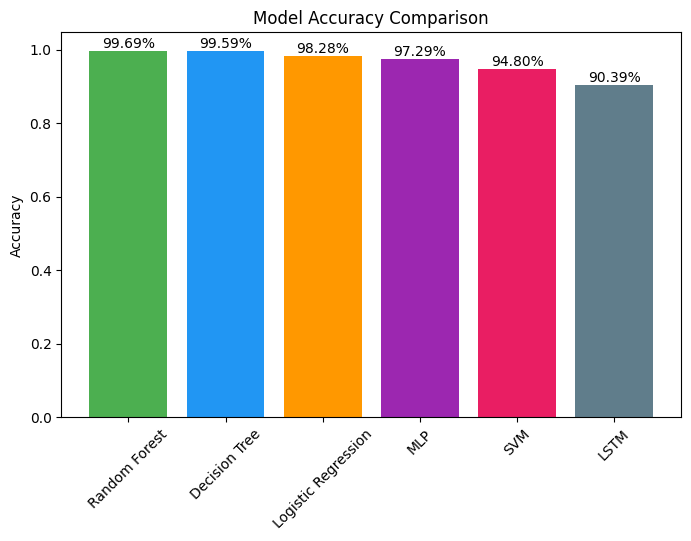

In [46]:
colors = ["#4CAF50","#2196F3","#FF9800","#9C27B0","#E91E63","#607D8B"]

plt.figure(figsize=(8,5))
bars = plt.bar(results_df["Model"], results_df["Accuracy"], color=colors)

plt.xticks(rotation=45)
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{height*100:.2f}%",
        ha='center',
        va='bottom'
    )

plt.show()

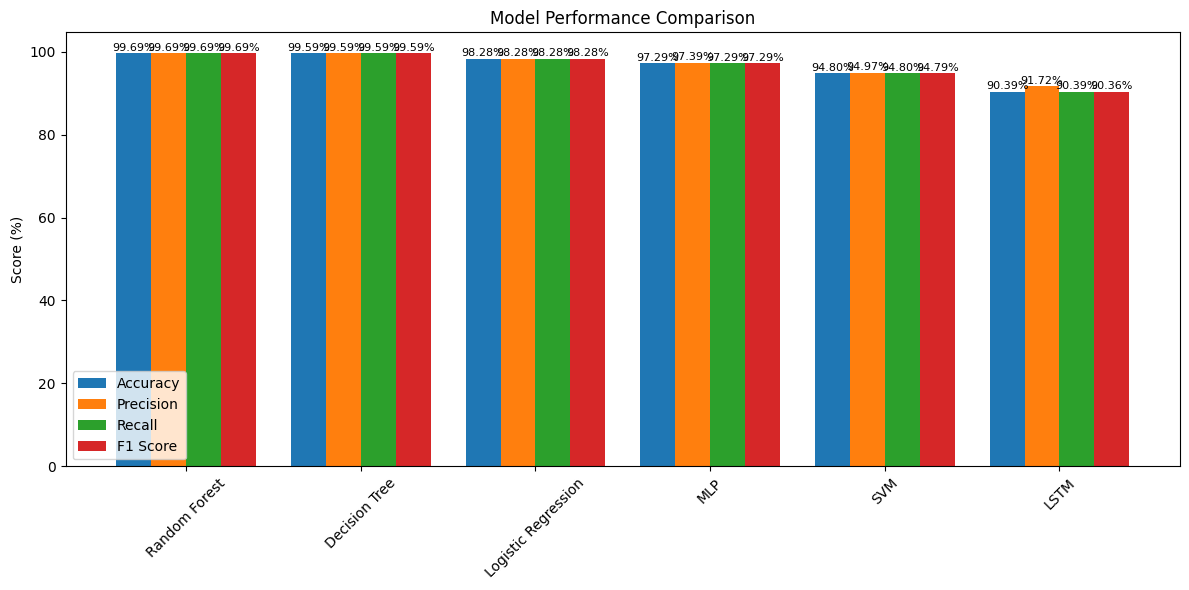

In [47]:
import matplotlib.pyplot as plt
import numpy as np

metrics = ["Accuracy", "Precision", "Recall", "F1 Score"]
models = results_df["Model"]

x = np.arange(len(models))
width = 0.2

plt.figure(figsize=(12,6))

for i, metric in enumerate(metrics):
    values = results_df[metric] * 100  # convert to %
    bars = plt.bar(x + i*width, values, width, label=metric)

    # add % labels on bars
    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width()/2,
            height + 0.1,
            f"{height:.2f}%",
            ha='center',
            va='bottom',
            fontsize=8
        )

plt.xticks(x + width*1.5, models, rotation=45)
plt.ylabel("Score (%)")
plt.title("Model Performance Comparison")
plt.legend()
plt.tight_layout()
plt.show()

# ***Heatmap***

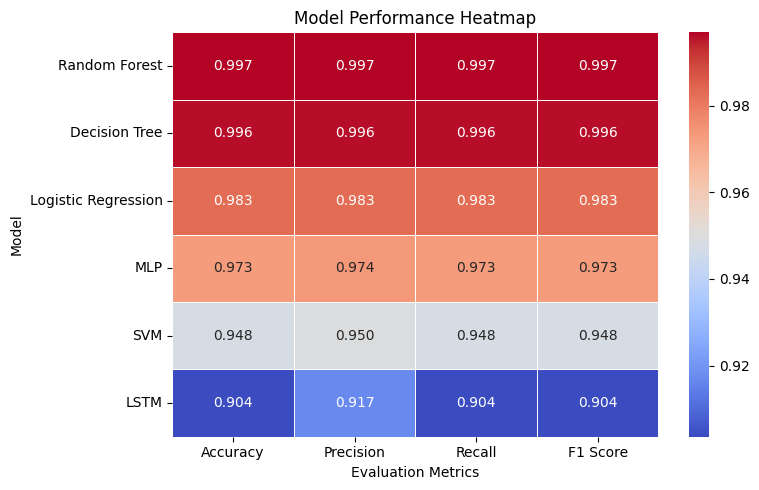

In [45]:
heatmap_data = results_df.set_index("Model")[["Accuracy", "Precision", "Recall", "F1 Score"]]

plt.figure(figsize=(8,5))

sns.heatmap(
    heatmap_data,
    annot=True,
    cmap="coolwarm",
    fmt=".3f",
    linewidths=0.5
)

plt.title("Model Performance Heatmap")
plt.ylabel("Model")
plt.xlabel("Evaluation Metrics")

plt.tight_layout()
plt.show()

# ***Accuracy vs Training Time***

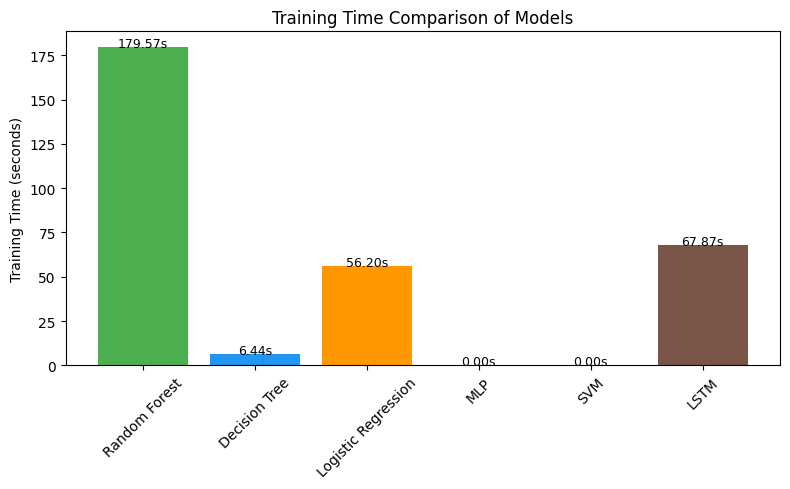

In [48]:
plt.figure(figsize=(8,5))

bars = plt.bar(
    results_df["Model"],
    results_df["Training Time (s)"],
    color=["#4CAF50","#2196F3","#FF9800","#9C27B0","#E91E63","#795548"]
)

# add time labels on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.1,
        f"{height:.2f}s",
        ha="center",
        fontsize=9
    )

plt.xticks(rotation=45)
plt.ylabel("Training Time (seconds)")
plt.title("Training Time Comparison of Models")

plt.tight_layout()
plt.show()

***Saving the model***

In [49]:
pickle.dump(dt_pipeline, open("decision_tree.pkl", "wb"))
pickle.dump(rf_pipeline, open("random_forest.pkl", "wb"))
pickle.dump(lr_pipeline, open("logistic_regression.pkl", "wb"))
pickle.dump(svm_pipeline, open("svm.pkl", "wb"))
pickle.dump(mlp_pipeline, open("mlp.pkl", "wb"))

model.save("lstm_model.h5")

post the saved models on github